# Creating embeddings

In this exercise, you'll create your very first embeddings using the OpenAI API.
Normally, to interact with the OpenAI API, you would need an OpenAI API key,
and creating embeddings would incur a cost.

In [6]:
from openai_helper import client

# Create a request to obtain embeddings
response = client.embeddings.create(
    model="text-embedding-3-small", input="What is your name?"
)

# Convert the response into a dictionary
response_dict = response.model_dump()
print(response_dict["data"][0]["embedding"][:10])

[0.03619384765625, -0.03662109375, -0.039276123046875, 0.01302337646484375, -0.0592041015625, -0.01910400390625, -0.01116180419921875, 0.00832366943359375, -0.0225372314453125, -0.052154541015625]


Digging into the embeddings response
You've been able to successfully use the OpenAI Embeddings endpoint to embed text data, 
and in this exercise, 
you'll finish this off by extracting information from the API's response.

You've been provided with a response from the Embeddings API, 
which has already been converted into a dictionary and stored as response_dict. 
You'll need to extract the desired information from this dictionary. 
This response_dict has been printed for you, so you can view its contents and structure.

Recall that the response is structured like a nested Python dictionary, 
and it can be accessed in much the same way.

In [7]:
# Extract the total_tokens from response_dict
print(response_dict["usage"]["total_tokens"])

5


# Embedding product descriptions

You've been provided with a list of dictionaries called products,
which contains product information for different products sold by an online retailer.
It's your job to embed the 'short_description' for each product
to enable semantic search for the retailer's website.

Here's a preview of the products list of dictionaries:
```python
products = [
    {
        "title": "Smartphone X1",
        "short_description": "The latest flagship smartphone with AI-powered features and 5G connectivity.",
        "price": 799.99,
        "category": "Electronics",
        "features": [
            "6.5-inch AMOLED display",
            "Quad-camera system with 48MP main sensor",
            "Face recognition and fingerprint sensor",
            "Fast wireless charging"
        ]
    },
    ...
]
```

In [12]:
import matplotlib.pyplot as plt
import numpy as np
from DATA import products
from openai_helper import client
from sklearn.manifold import TSNE

In [14]:
# Extract a list of product short description from products
product_descriptions = [product["short_description"] for product in products]
# print(len(product_descriptions))

# Create embeddings foreach product description
response = client.embeddings.create(
    model="text-embedding-3-small",
    input=product_descriptions,
)

response_dict = response.model_dump()

# Extract the embeddings from response_dict and store in products
for i, product in enumerate(products):
    product["embedding"] = response_dict["data"][i]["embedding"]

print(products[0].items())

dict_items([('title', 'Smartphone X1'), ('short_description', 'The latest flagship smartphone with AI-powered features and 5G connectivity.'), ('price', 799.99), ('category', 'Electronics'), ('features', ['6.5-inch AMOLED display', 'Quad-camera system with 48MP main sensor', 'Face recognition and fingerprint sensor', 'Fast wireless charging']), ('embedding', [0.0168609619140625, -0.0127716064453125, -0.0228271484375, 0.0218048095703125, 0.01377105712890625, -0.0016298294067382812, 0.013702392578125, 0.037017822265625, 0.032135009765625, -0.01253509521484375, -0.04058837890625, -0.033233642578125, -0.06597900390625, -0.0638427734375, -0.03125, -0.047576904296875, -0.07537841796875, 0.0026302337646484375, 0.0640869140625, -0.01117706298828125, -0.0257568359375, 0.0035076141357421875, 0.0298614501953125, -0.01399993896484375, -0.0009570121765136719, -0.029296875, -0.0638427734375, 0.0200653076171875, 0.017486572265625, 0.01849365234375, 0.01513671875, -0.041168212890625, 0.037353515625, -

Visualizing the embedded descriptions
Now that you've created embeddings from the product descriptions,
it's time to explore them!
You'll use t-SNE to reduce the number of dimensions in the embeddings data from 1,536 to two,
which will make the data much easier to visualize.

You'll start with the products list of dictionaries you worked with in the last exercise,
containing product information and the embeddings you created from the 'short_description'.

In [18]:
# Create categories and embeddings lists using list comprehensions
categories = [product["category"] for product in products]
embeddings = [product["embedding"] for product in products]

In [19]:
# Reduce the number of embeddings dimensions to two using t-SNE
tsne = TSNE(n_components=2, perplexity=5)
embeddings_2d = tsne.fit_transform(np.array(embeddings))

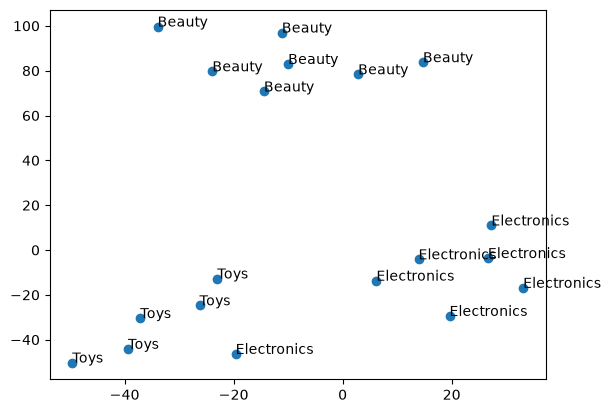

In [20]:
# Create a scatter plot from embeddings_2d
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1])

for i, category in enumerate(categories):
    plt.annotate(category, (embeddings_2d[i, 0], embeddings_2d[i, 1]))

plt.show()